# ResMill Tutorial

One concise walk-through of every reservoir-architecture layer ResMill
supports. Defaults are tuned so each layer renders a fully-populated
reservoir on the standard 64×64×32 grid out of the box — pass nothing
but the grid and you get a sensible result.

* **`MeanderingChannelLayer`** — fluvial channel system. Five named
  reservoir architectures shipped as preset dicts you splat into
  `create_geology(**PRESET)`: `PV_SHOESTRING`, `CB_LABYRINTH`,
  `SH_DISTAL`, `SH_PROXIMAL`, plus `MEANDER_OXBOW` (single sinuous
  channel with neck cutoffs and oxbow mud plugs).
* **`BraidedChannelLayer`** — same engine, defaults baked in to the
  `CB_JIGSAW` architecture.
* **`DeltaLayer`** — distributary fan, fluvial-engine driven
  (`DELTA_FAN` defaults).
* **`LobeLayer`** — turbidite lobes with compensational stacking.
* **`Reservoir`** — vertically stacks any of the above into a
  contiguous 3D model; users can interleave shales / sands / channels
  by choosing the order.

Outputs every layer exposes:

* `layer.facies` — Alluvsim 6-class array (-1=FF, 0=FFCH, 1=CS,
  2=LV, 3=LA, 4=CH).
* `layer.active` — binary 0/1 sand mask.
* `layer.poro_mat` / `layer.perm_mat` — per-cell continuous arrays.

In [1]:
import numpy as np
import resmill as rm
from resmill.layers.channel import (
    PV_SHOESTRING, CB_LABYRINTH, SH_DISTAL, SH_PROXIMAL, MEANDER_OXBOW,
)
%matplotlib inline

# Standard 64×64×32 grid used everywhere in this tutorial and in
# examples/dataset_generation/config_*.json.
GRID = dict(nx=64, ny=64, nz=32, x_len=640, y_len=640, z_len=32, top_depth=0)

## 1. Turbidite lobe layer

Compensational stacking of turbidite lobes — each successive lobe is
preferentially deposited in the topographic low left by previous ones.
Defaults give a populated lobe field; pass any `**kwargs` to tune
(porosity / permeability stats, lobe radius, aspect ratio, Bouma
factor, upthinning, etc.).

NTG= 70.0%  FF=30.0%  LA=70.0%


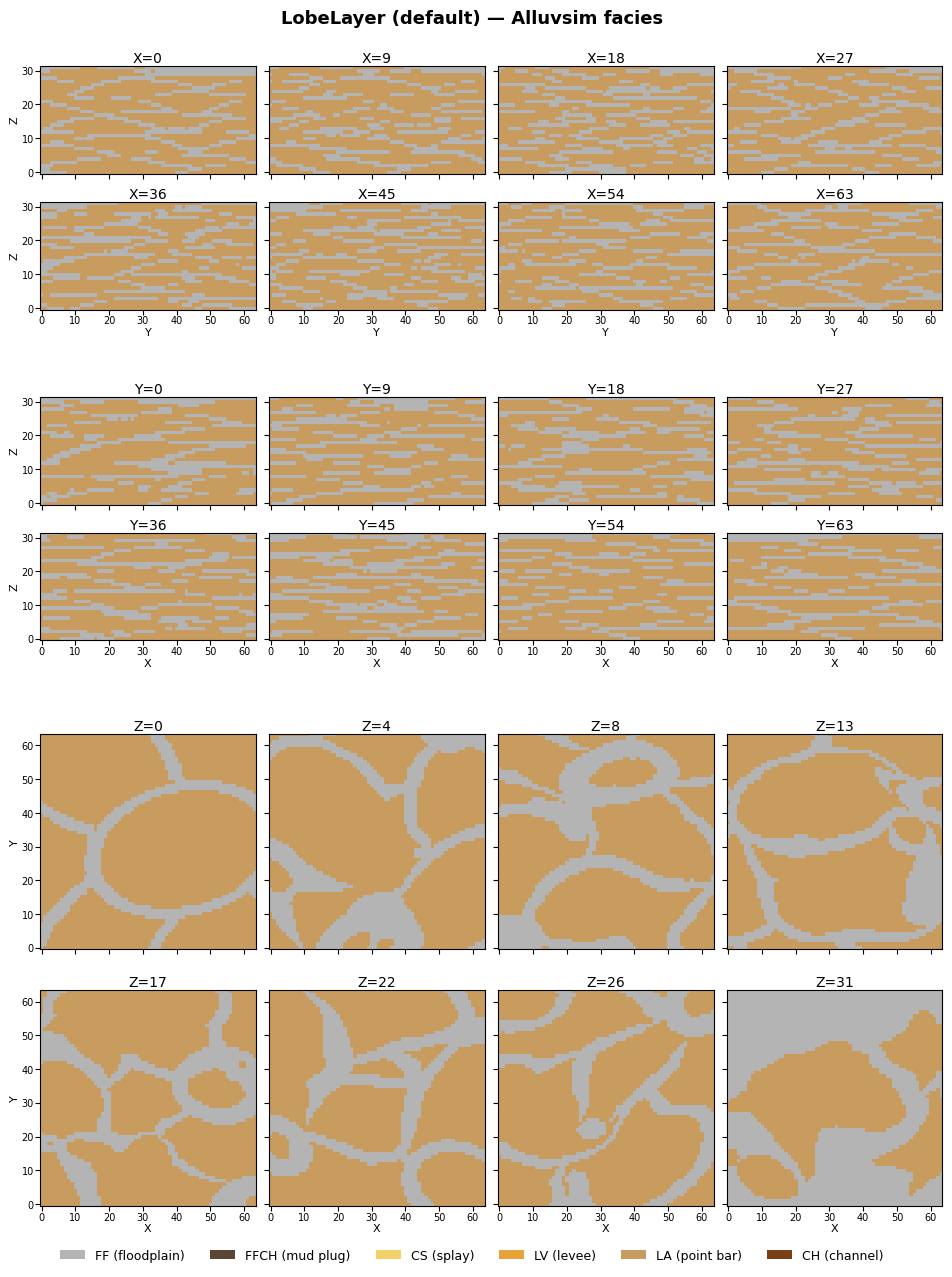

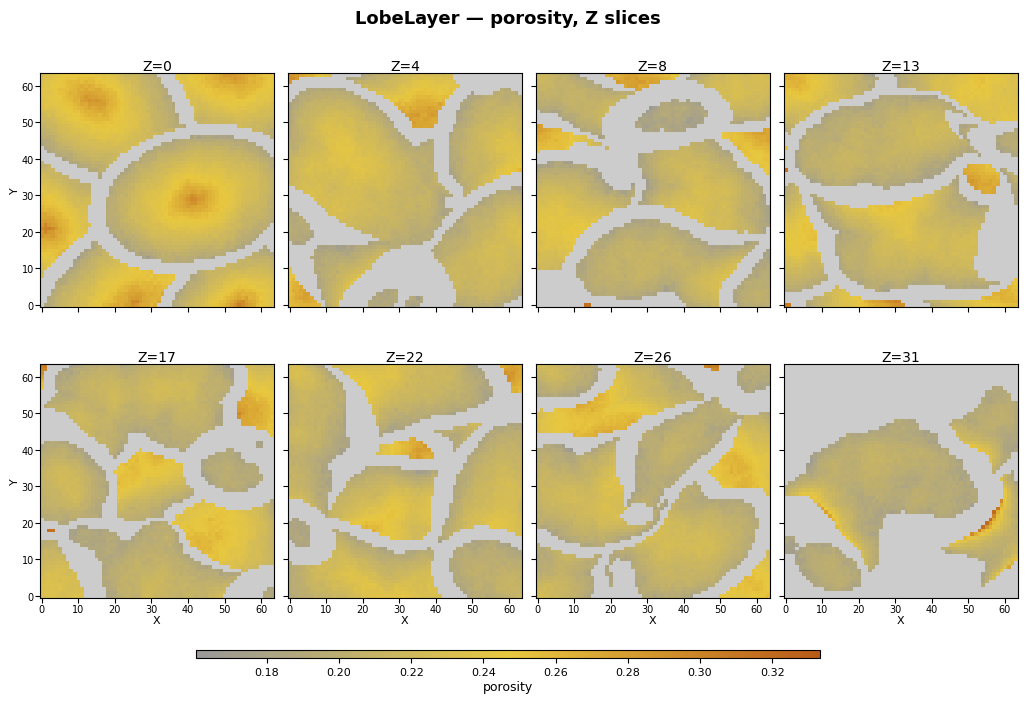

In [2]:
lobe = rm.LobeLayer(**GRID)
lobe.create_geology(
    poro_ave=0.20, perm_ave=1.5, poro_std=0.03, perm_std=0.5, ntg=0.7,
    rmin=15, rmax=25, asp=1.5, m=100, upthinning=False,
)
rm.plot_slices(lobe, title='LobeLayer (default) — Alluvsim facies')
rm.plot_slices(lobe.poro_mat, axis=2, title='LobeLayer — porosity, Z slices')

## 2. Meandering channel layer

Fluvial channel system driven by the Alluvsim event-loop engine
(AR(2) walks + Sun-1996 bank-retreat migration + avulsion + neck
cutoff + level aggradation). The `MeanderingChannelLayer` defaults
alone produce a populated reservoir; the five named architectures
override the defaults via preset dicts. See
`tutorial_alluvsim.ipynb` for parameter sweeps and full Alluvsim docs.

NTG= 11.0%  FF=89.0%  CS=1.0%  LV=0.5%  LA=3.3%  CH=6.2%


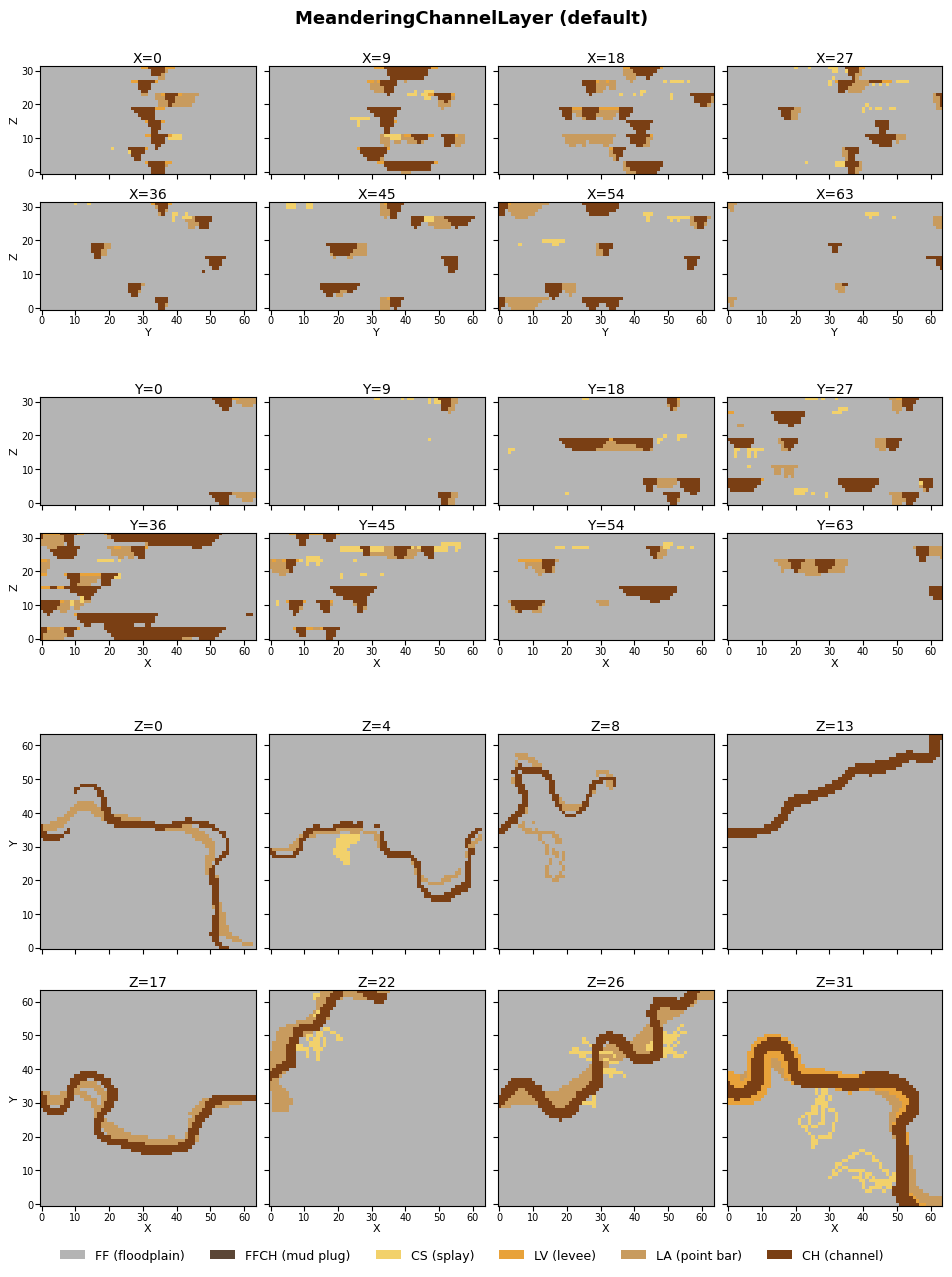

In [3]:
# Defaults — no preset, no kwargs. Always works.
channel = rm.MeanderingChannelLayer(**GRID)
channel.create_geology(seed=42)
rm.plot_slices(channel, title='MeanderingChannelLayer (default)')

NTG= 10.3%  FF=89.7%  CS=0.9%  LV=0.1%  LA=3.4%  CH=5.8%


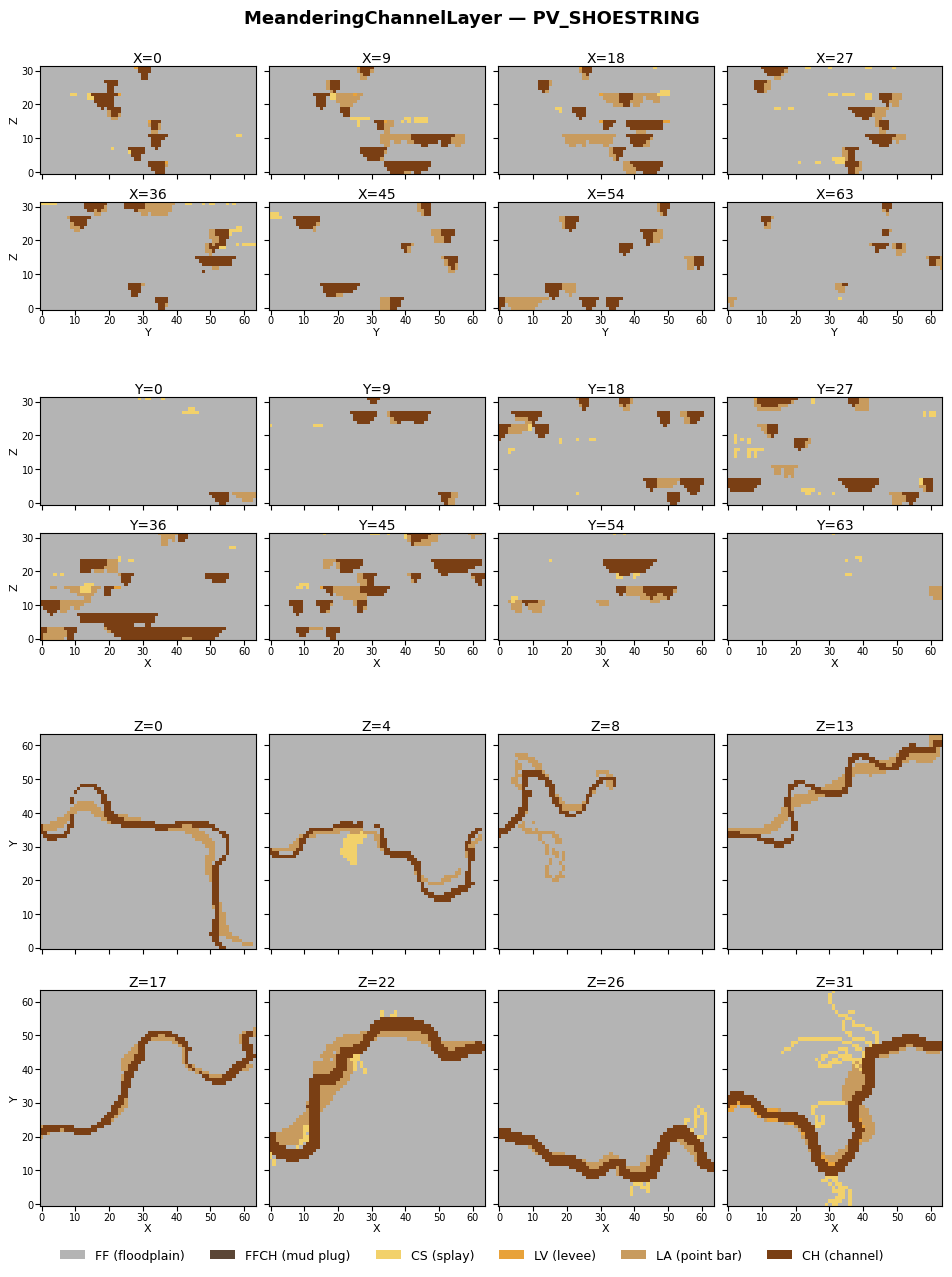

In [4]:
# PV_SHOESTRING — paleo-valley shoestring (low-NTG single sinuous
# channel with prominent LA point bars; cf. Cretaceous Cardium Fm).
channel = rm.MeanderingChannelLayer(**GRID)
channel.create_geology(seed=42, **PV_SHOESTRING)
rm.plot_slices(channel, title='MeanderingChannelLayer — PV_SHOESTRING')

NTG= 25.2%  FF=69.6%  FFCH=5.2%  CS=3.7%  LA=13.5%  CH=8.0%


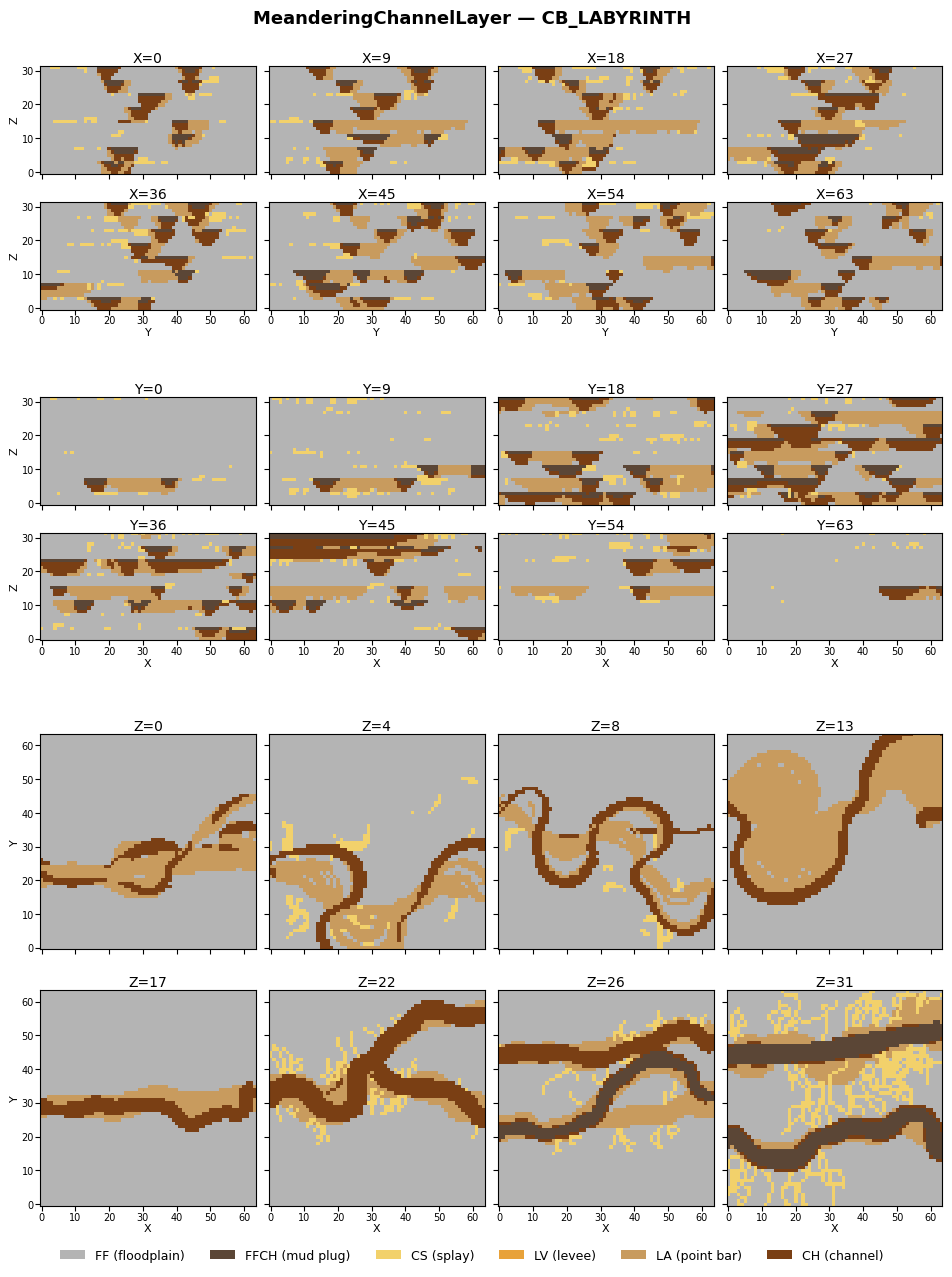

In [5]:
# CB_LABYRINTH — many aggradation levels, low avulsion. Isolated
# CH lenses at distinct Z elevations (cf. Tertiary Tyler Fm).
channel = rm.MeanderingChannelLayer(**GRID)
channel.create_geology(seed=42, **CB_LABYRINTH)
rm.plot_slices(channel, title='MeanderingChannelLayer — CB_LABYRINTH')

NTG= 50.6%  FF=49.4%  CS=1.9%  LV=9.6%  LA=19.8%  CH=19.2%


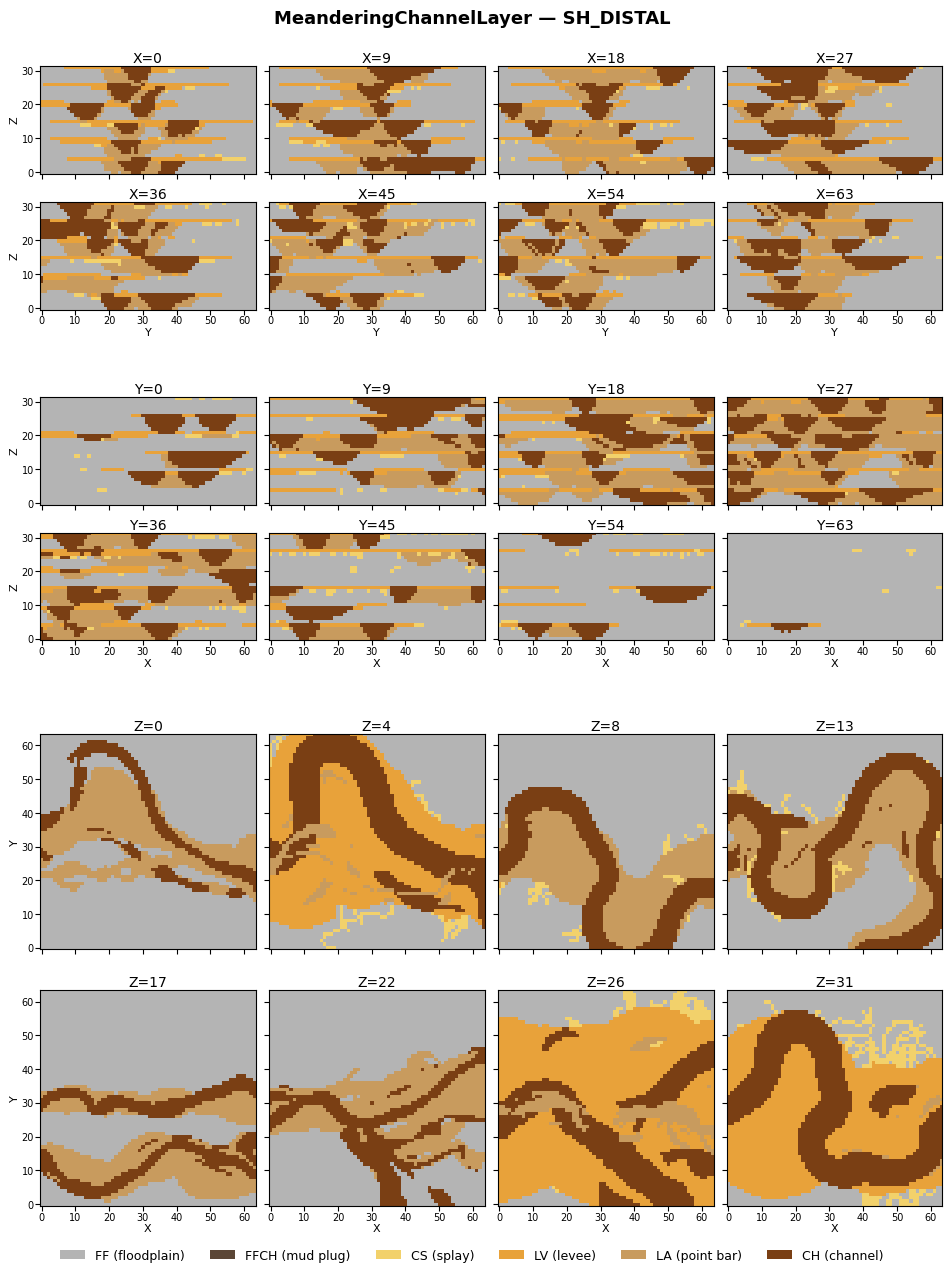

In [6]:
# SH_DISTAL — high-NTG sand sheet with thick LV blanket overbank
# (cf. distal Booch sandstone, Arkoma Basin).
channel = rm.MeanderingChannelLayer(**GRID)
channel.create_geology(seed=42, **SH_DISTAL)
rm.plot_slices(channel, title='MeanderingChannelLayer — SH_DISTAL')

NTG= 40.2%  FF=57.7%  FFCH=2.1%  CS=3.6%  LA=8.9%  CH=27.7%


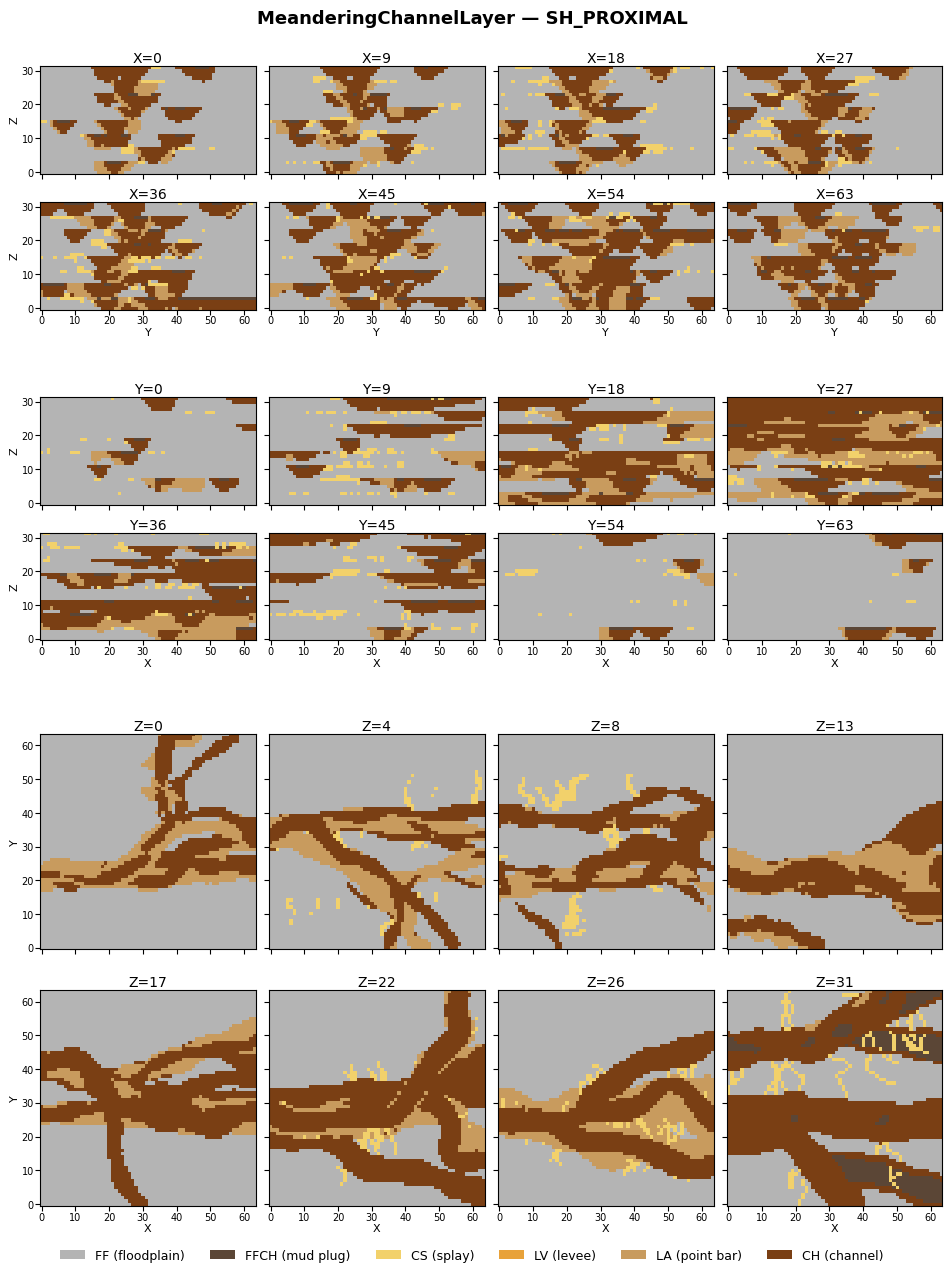

In [7]:
# SH_PROXIMAL — heavy avulsion + wide shallow channels = fully
# amalgamated sand body with FFCH mud plugs marking abandonments
# (cf. proximal Booch sandstone).
channel = rm.MeanderingChannelLayer(**GRID)
channel.create_geology(seed=42, **SH_PROXIMAL)
rm.plot_slices(channel, title='MeanderingChannelLayer — SH_PROXIMAL')

NTG= 23.9%  FF=75.6%  FFCH=0.5%  LV=0.9%  LA=11.5%  CH=11.5%


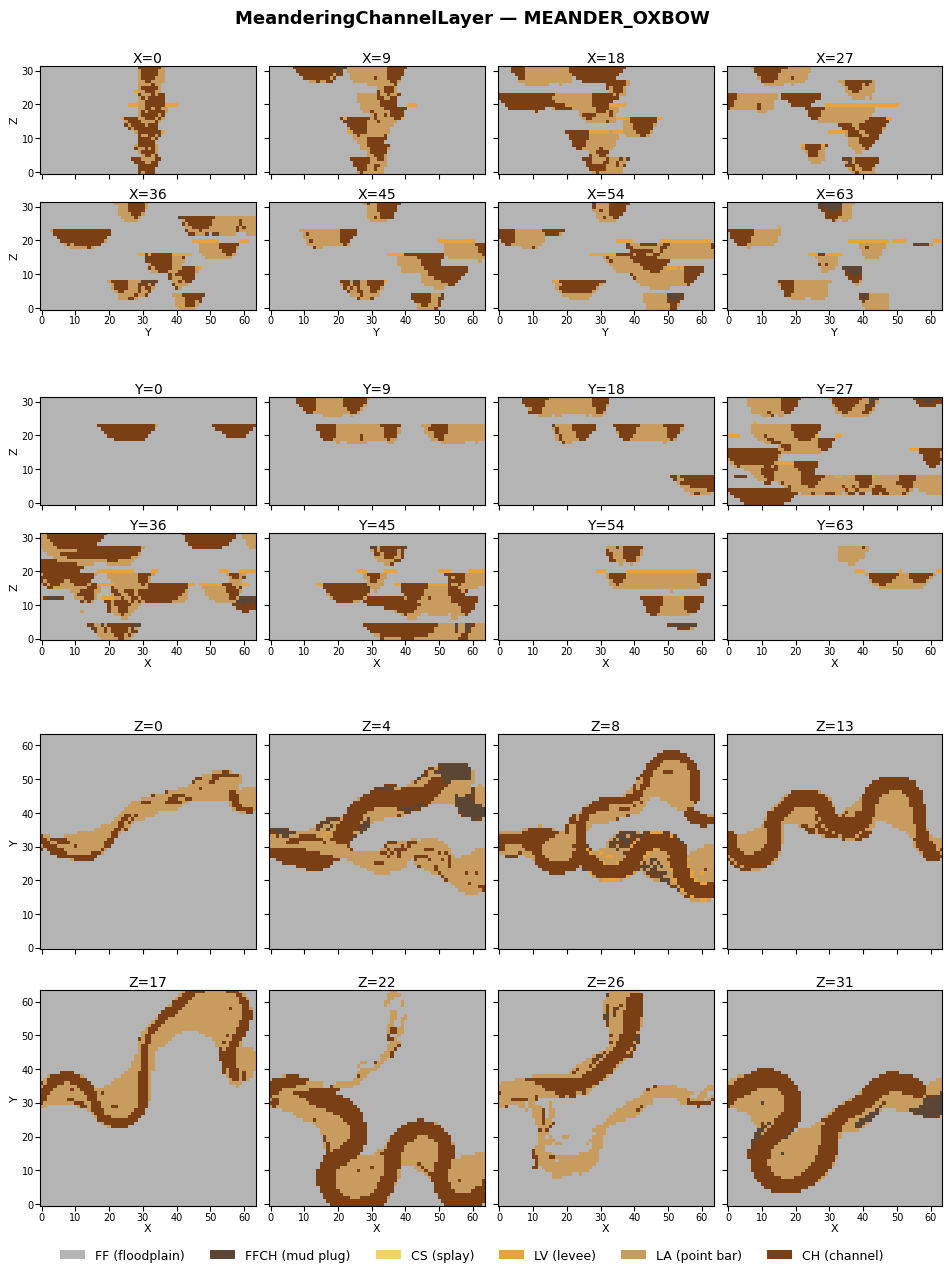

In [8]:
# MEANDER_OXBOW — one sinuous channel migrating across the floodplain
# until tight bends pinch off into oxbow loops. Each cutoff is painted
# as an FFCH mud plug (mNeckFFCHprop=0.6) with a residual CH lag —
# the classic neck-cutoff → oxbow lake → mud plug succession,
# stacked vertically into a multi-storey channel sandstone.
channel = rm.MeanderingChannelLayer(**GRID)
channel.create_geology(seed=42, **MEANDER_OXBOW)
rm.plot_slices(channel, title='MeanderingChannelLayer — MEANDER_OXBOW')

## 3. Braided channel layer

Same engine as `MeanderingChannelLayer`, just with the `CB_JIGSAW`
preset baked in: shallow wide channels, aggressive in-model avulsion,
prominent FFCH mud-plug baffles. Calling `create_geology()` with no
kwargs gives the canonical CB-jigsaw architecture.

NTG= 29.9%  FF=58.2%  FFCH=11.8%  CS=5.7%  LA=9.6%  CH=14.7%


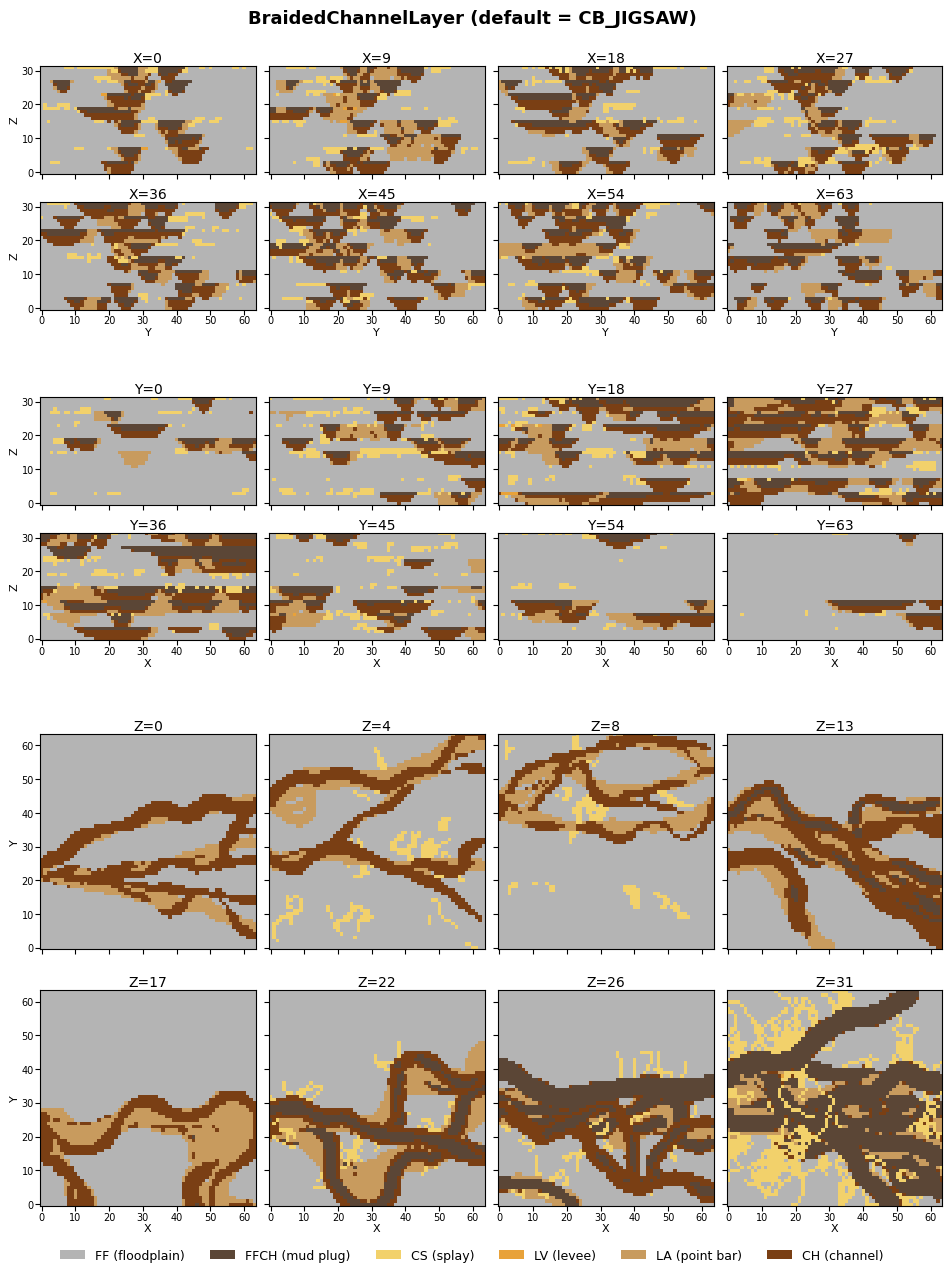

In [9]:
braided = rm.BraidedChannelLayer(**GRID)
braided.create_geology(seed=42)
rm.plot_slices(braided, title='BraidedChannelLayer (default = CB_JIGSAW)')

## 4. Delta layer

Distributary fan — subclass of `MeanderingChannelLayer` driving the
same fluvial engine with delta-tuned defaults (`DELTA_FAN`). Knobs
unique to delta: `trunk_length_fraction` (where bifurcation starts),
`progradation_fraction` (clinoform), `branch_spread_deg` (fan-out
angle), `paint_mouth_bars` (calc_lobe envelopes at distal tips). See
`tutorial_delta.ipynb` for the full delta walkthrough.

NTG= 28.7%  FF=71.3%  LA=3.8%  CH=25.0%


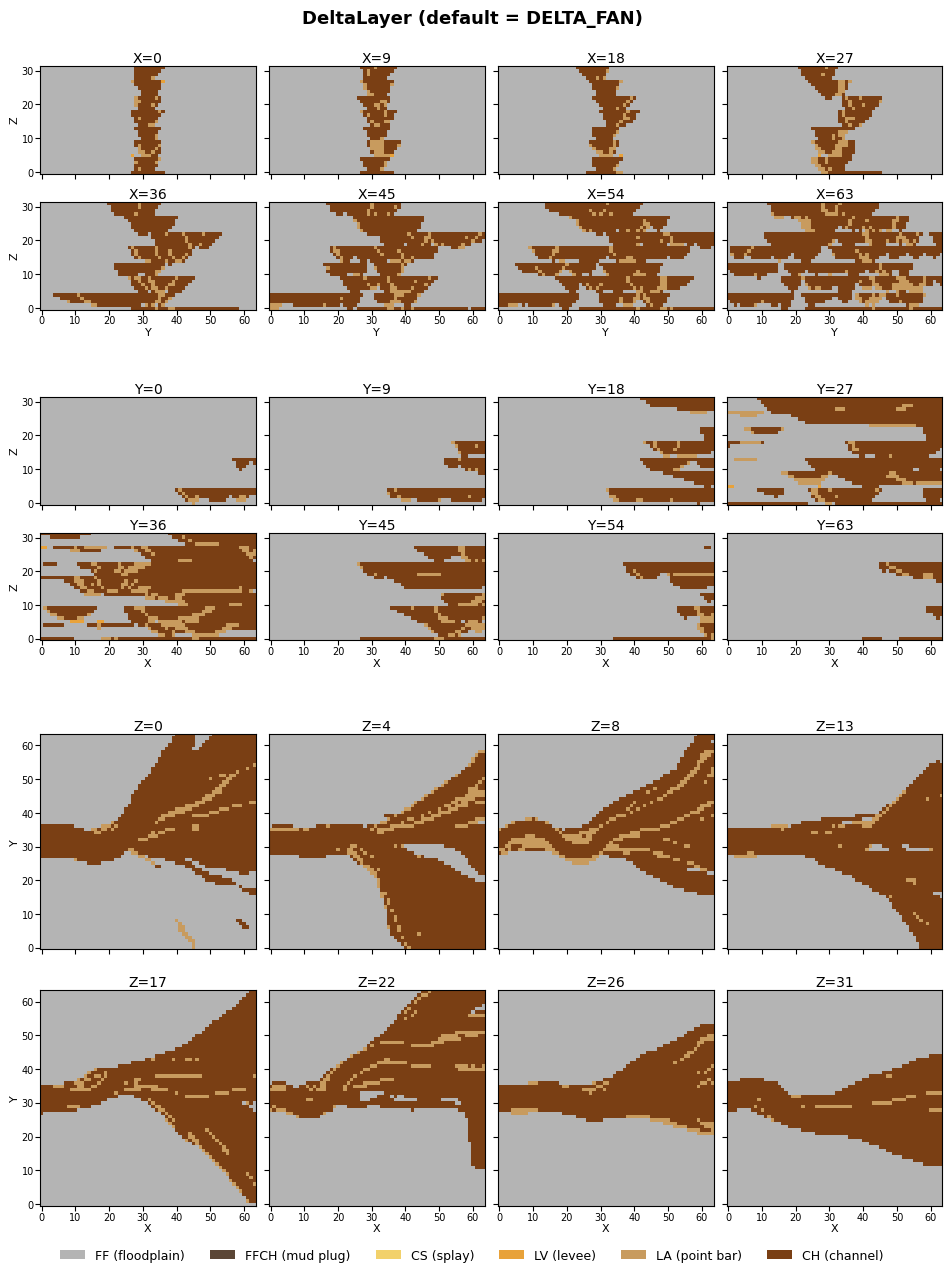

In [10]:
delta = rm.DeltaLayer(**GRID)
delta.create_geology(seed=42)
rm.plot_slices(delta, title='DeltaLayer (default = DELTA_FAN)')

## 5. Stacking layers into a Reservoir

Each layer is one architectural unit. To compose a multi-storey
reservoir — alternating channels, lobes, shaly background, deltas —
build each layer with matching `nx`, `ny`, `x_len`, `y_len` and
contiguous `top_depth`/`z_len`, then pass the list to `Reservoir`.

Reservoir shape: (64, 64, 32)  (top→bottom: delta + lobe + meandering channel with oxbows)


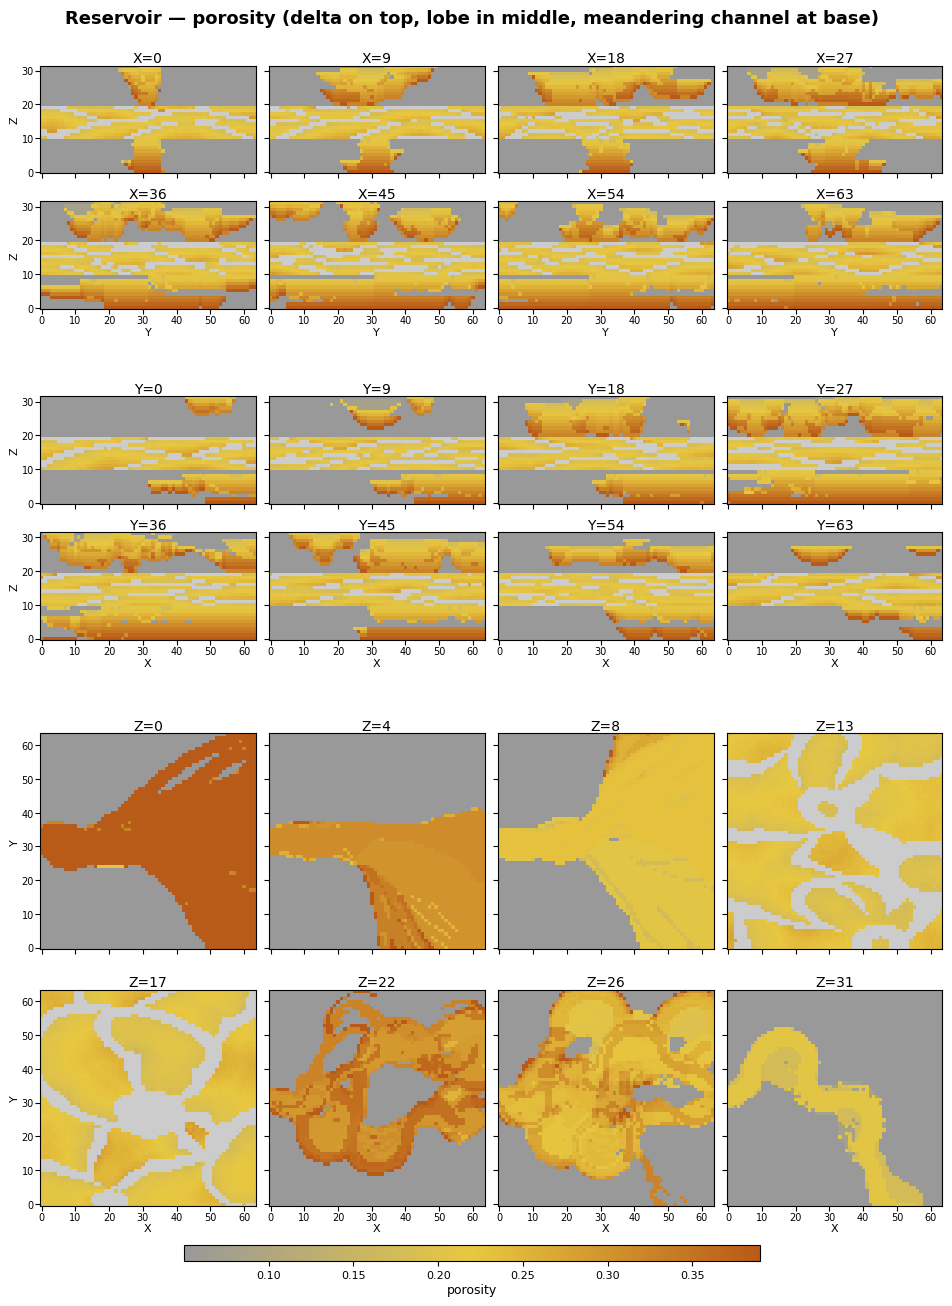

In [11]:
nx, ny = 64, 64
x_len, y_len = 640, 640

# Top: delta fan, 10 m thick (top_depth=5000, bottom=5010)
top = rm.DeltaLayer(nx=nx, ny=ny, nz=10, x_len=x_len, y_len=y_len,
                     z_len=10, top_depth=5000)
top.create_geology(seed=3)

# Middle: lobe blanket, 10 m thick (top=5010, bottom=5020)
mid = rm.LobeLayer(nx=nx, ny=ny, nz=10, x_len=x_len, y_len=y_len,
                    z_len=10, top_depth=5010)
mid.create_geology(poro_ave=0.20, perm_ave=1.5, poro_std=0.03, perm_std=0.5,
                    ntg=0.7, rmin=12, rmax=22, upthinning=False)

# Bottom: meandering channel with oxbow cutoffs, 12 m thick (top=5020, bottom=5032)
bot = rm.MeanderingChannelLayer(nx=nx, ny=ny, nz=12, x_len=x_len, y_len=y_len,
                                  z_len=12, top_depth=5020)
bot.create_geology(seed=1, **MEANDER_OXBOW)

# Reservoir takes layers in top→bottom order. Each layer's bottom
# (top_depth + z_len) must match the next layer's top_depth.
reservoir = rm.Reservoir([top, mid, bot])
print(f'Reservoir shape: {reservoir.poro_mat.shape}  '
       f'(top→bottom: delta + lobe + meandering channel with oxbows)')
rm.plot_slices(reservoir.poro_mat,
               title='Reservoir — porosity (delta on top, lobe in middle, meandering channel at base)')